Doing preprocessing on Credit Card Transactions Fraud Detection dataset from kaggle with google colab

URL
https://www.kaggle.com/datasets/kartik2112/fraud-detection?select=fraudTrain.csv

In [38]:
import pandas as pd
import datetime
import numpy as np

importing dataset

In [39]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection


In [40]:
import pandas as pd
import os

# List files in the downloaded directory to verify names
files = os.listdir(path)
print("Files in dataset:", files)

# Load the training and testing sets
# The dataset contains 'fraudTrain.csv' and 'fraudTest.csv'
train_df = pd.read_csv(os.path.join(path, 'fraudTrain.csv'))
test_df = pd.read_csv(os.path.join(path, 'fraudTest.csv'))

# Preview the data
print(f"Training data loaded with {train_df.shape[0]} rows.")
train_df.head()


Files in dataset: ['fraudTest.csv', 'fraudTrain.csv']
Training data loaded with 1296675 rows.


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [41]:
df = pd.concat([train_df, test_df])
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


Training set for Credit Card Transactions

index - Unique Identifier for each row

trans_date_trans_time - Transaction DateTime

cc_num - Credit Card Number of Customer

merchant - Merchant Name

category - Category of Merchant

amt - Amount of Transaction

first - First Name of Credit Card Holder

last - Last Name of Credit Card Holder

gender - Gender of Credit Card Holder

street - Street Address of Credit Card Holder

city - City of Credit Card Holder

state - State of Credit Card Holder

zip - Zip of Credit Card Holder

lat - Latitude Location of Credit Card Holder

long - Longitude Location of Credit Card Holder

city_pop - Credit Card Holder's City Population

job - Job of Credit Card Holder

dob - Date of Birth of Credit Card Holder

trans_num - Transaction Number

unix_time - UNIX Time of transaction

merch_lat - Latitude Location of Merchant

merch_long - Longitude Location of Merchant

is_fraud - Fraud Flag <--- Target Class

In [42]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

droping useless columns

In [43]:
df.drop(['Unnamed: 0','cc_num','merchant','first','last','street', 'city', 'state', 'zip','city_pop','trans_num','job','unix_time'],axis=1,inplace=True)

In [44]:
df.shape

(1852394, 10)

In [45]:
df.isnull().sum()

,0
trans_date_trans_time,0
category,0
amt,0
gender,0
lat,0
long,0
dob,0
merch_lat,0
merch_long,0
is_fraud,0


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.head()

,trans_date_trans_time,category,amt,gender,lat,long,dob,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,misc_net,4.97,F,36.0788,-81.1781,1988-03-09,36.011293,-82.048315,0
1,2019-01-01 00:00:44,grocery_pos,107.23,F,48.8878,-118.2105,1978-06-21,49.159047,-118.186462,0
2,2019-01-01 00:00:51,entertainment,220.11,M,42.1808,-112.2620,1962-01-19,43.150704,-112.154481,0
3,2019-01-01 00:01:16,gas_transport,45.00,M,46.2306,-112.1138,1967-01-12,47.034331,-112.561071,0
4,2019-01-01 00:03:06,misc_pos,41.96,M,38.4207,-79.4629,1986-03-28,38.674999,-78.632459,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   category               object 
 2   amt                    float64
 3   gender                 object 
 4   lat                    float64
 5   long                   float64
 6   dob                    object 
 7   merch_lat              float64
 8   merch_long             float64
 9   is_fraud               int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 155.5+ MB


In [49]:
df['is_fraud'].value_counts()/df.shape[0]*100

,count
is_fraud,
0,99.478999
1,0.521001


imbalance dataset

In [50]:
df['gender'].value_counts()/df.shape[0]*100

,count
gender,
F,54.780408
M,45.219592


feature engineering

In [51]:
df['category'].value_counts()/df.shape[0]*100

,count
category,
gas_transport,10.150594
grocery_pos,9.511529
home,9.472067
shopping_pos,8.986371
kids_pets,8.730702
shopping_net,7.521186
entertainment,7.240252
food_dining,7.057300
personal_care,7.022534


In [52]:
df['category'] = df['category'].str.replace('_',' ')

In [53]:
df['category'] = df['category'].str.split(" ").str[0]

In [54]:
df['category'] = df['category'].str.replace('kids','home')
df['category'] = df['category'].str.replace('gas','travel')
df['category'] = df['category'].str.replace('food','grocery')

In [55]:
df['category'].value_counts()/df.shape[0]*100

,count
category,
grocery,20.071216
home,18.202769
shopping,16.507557
travel,13.279302
misc,11.060444
entertainment,7.240252
personal,7.022534
health,6.615925


In [56]:
df['dob'] = pd.to_datetime(df['dob'])

In [57]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [58]:
df['age'] = (df['trans_date_trans_time'].dt.year - df['dob'].dt.year).astype('int64')

<Axes: ylabel='Frequency'>

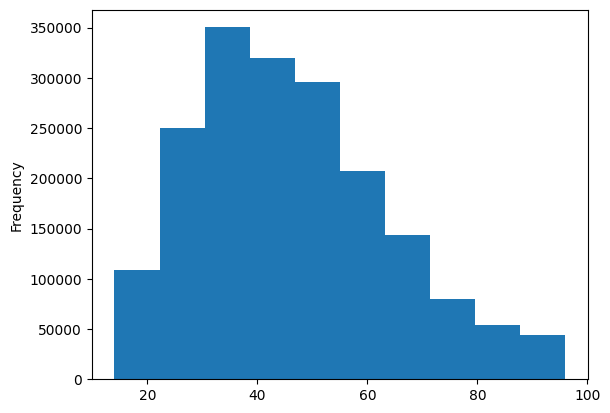

In [59]:
df['age'].plot(kind='hist')

In [60]:
df.drop(['dob'],axis=1,inplace=True)

In [61]:
df['day']=df['trans_date_trans_time'].dt.strftime('%a')

In [62]:
df['hour'] = df['trans_date_trans_time'].dt.hour

In [63]:
df.drop(['trans_date_trans_time'],axis=1,inplace=True)

In [64]:
import numpy as np

def calculate_distance(lat1, lon1, lat2, lon2):
    # Earth's radius
    R = 6371.0

    # Convert all coordinates to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c


In [65]:
df['distance_km'] = df.apply(lambda row: calculate_distance(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)


In [66]:
df['distance_km'] = df['distance_km'].astype(int)

<Axes: ylabel='Frequency'>

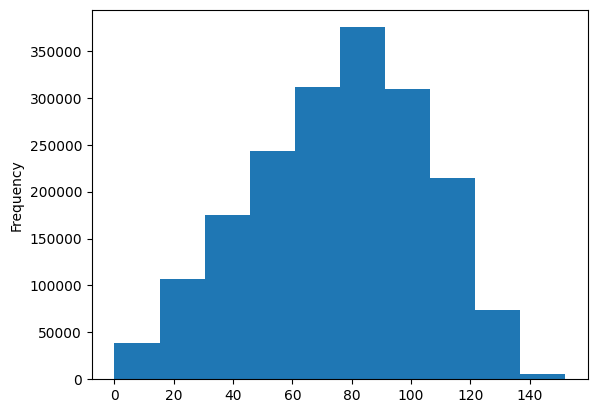

In [67]:
df['distance_km'].plot(kind='hist')

In [68]:
df.drop(['lat','long','merch_lat','merch_long'],axis=1,inplace=True)

In [69]:
df.head()

,category,amt,gender,is_fraud,age,day,hour,distance_km
0,misc,4.97,F,0,31,Tue,0,78
1,grocery,107.23,F,0,41,Tue,0,30
2,entertainment,220.11,M,0,57,Tue,0,108
3,travel,45.00,M,0,52,Tue,0,95
4,misc,41.96,M,0,33,Tue,0,77


In [70]:
bins = [0, 20, 60, 80, 120, np.inf]
labels = ['Local', 'Commute', 'Regional', 'Long_Distance', 'Remote']

local  0-20

Commute 20-60

Regional 60-80

Long_Distance 80-120

Remote 120-...

In [71]:
df['distance_km'] = pd.cut(df['distance_km'],labels=labels,bins=bins)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 8 columns):
 #   Column       Dtype   
---  ------       -----   
 0   category     object  
 1   amt          float64 
 2   gender       object  
 3   is_fraud     int64   
 4   age          int64   
 5   day          object  
 6   hour         int32   
 7   distance_km  category
dtypes: category(1), float64(1), int32(1), int64(2), object(3)
memory usage: 107.8+ MB


In [73]:
df.shape

(1852394, 8)

dealing with imbalance data

In [76]:
df['is_fraud'].value_counts()/df.shape[0]

,count
is_fraud,
0,0.99479
1,0.00521


In [77]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,1842743
1,9651


In [78]:
def make_dataset(num):
  for i in range(1,num+1):
    x = df[df['is_fraud']==0].sample(9651)
    y = df[df['is_fraud']==1]
    data = pd.concat([x, y], axis=0)
    data.to_csv(f"data{i}.csv",index=False)
    print(f"Dataset {i} saved successfully.")


makeinf 7 subset of data

In [80]:
make_dataset(7)

Dataset 1 saved successfully.
Dataset 2 saved successfully.
Dataset 3 saved successfully.
Dataset 4 saved successfully.
Dataset 5 saved successfully.
Dataset 6 saved successfully.
Dataset 7 saved successfully.
